# Cat vs Dog Image Classification Using PyTorch CNN

## Project Overview

This project develops a Convolutional Neural Network (CNN) using PyTorch to classify images into two categories: Cats and Dogs.

The project covers image preprocessing, dataset preparation, CNN architecture design, model training, data augmentation, and performance evaluation.

## Objectives

- Understand how convolutional neural networks process images.
- Build and train a CNN using PyTorch.
- Apply data augmentation to improve generalization.
- Evaluate performance using accuracy, loss, a confusion matrix, and classification metrics.
- Create a reusable prediction pipeline for new images.

## Dataset

The project uses the Cats vs Dogs image dataset, with images resized to 128 × 128 pixels.

- Classes: Cat (0) and Dog (1)
- Candidate images: 24,998
- Training images: 19,998
- Validation images: 5,000

## Best Validation Result

- Model: CNN with data augmentation
- Validation accuracy: 81.92%
- Number of training epochs: 15

*Note: These are validation results, not results from a separate held-out test set.*

In [2]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
GPU available: True


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU name: Tesla T4


In [4]:
import os
import torch

PROJECT_DIR = "/content/cat_dog_cnn"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("GPU available:", torch.cuda.is_available())

Project directory: /content/cat_dog_cnn
GPU available: True


In [5]:
import urllib.request

# Check whether we can access the dataset website
url = "https://storage.googleapis.com"

try:
    response = urllib.request.urlopen(url, timeout=10)
    print("Internet access: Working")
except Exception as e:
    print("Internet access issue:", e)

Internet access issue: HTTP Error 400: Bad Request


In [6]:
import urllib.request

url = "https://www.google.com"

try:
    response = urllib.request.urlopen(url, timeout=10)
    print("Internet access: Working")
    print("HTTP status:", response.status)
except Exception as e:
    print("Connection error:", e)

Internet access: Working
HTTP status: 200


In [7]:
!wget -q --show-progress \
"https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" \
-O /content/cat_dog_cnn/catsdogs.zip

/content/cat_dog_cn 100%[===================>] 786.67M   173MB/s    in 7.8s    


In [8]:
import os

zip_path = "/content/cat_dog_cnn/catsdogs.zip"

if os.path.exists(zip_path):
    print("Dataset archive downloaded!")
    print("File size:", round(os.path.getsize(zip_path) / (1024 ** 2), 2), "MB")
else:
    print("Download not found. Please check the previous cell.")

Dataset archive downloaded!
File size: 786.67 MB


In [9]:
import zipfile
import os

# Location of our downloaded ZIP file
zip_path = "/content/cat_dog_cnn/catsdogs.zip"

# Folder where we want to extract the images
extract_path = "/content/cat_dog_cnn/dataset"

# Create the destination folder
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Files and folders:", os.listdir(extract_path))

Dataset extracted successfully!
Files and folders: ['CDLA-Permissive-2.0.pdf', 'PetImages', 'readme[1].txt']


In [10]:
import os

# Define the path to the main image folder
image_dir = "/content/cat_dog_cnn/dataset/PetImages"

# List the folders inside PetImages
print("Class folders:", os.listdir(image_dir))

# Define the paths for each class
cat_dir = os.path.join(image_dir, "Cat")
dog_dir = os.path.join(image_dir, "Dog")

# Count the files in each class folder
print("Number of Cat files:", len(os.listdir(cat_dir)))
print("Number of Dog files:", len(os.listdir(dog_dir)))

Class folders: ['Dog', 'Cat']
Number of Cat files: 12501
Number of Dog files: 12501


In [11]:
from PIL import Image
import os

# Select the first five filenames from each class
cat_files = os.listdir(cat_dir)[:5]
dog_files = os.listdir(dog_dir)[:5]

# Check the Cat images
for filename in cat_files:
    path = os.path.join(cat_dir, filename)

    try:
        with Image.open(path) as img:
            img.verify()
        print("Valid Cat image:", filename)
    except Exception:
        print("Invalid Cat image:", filename)

# Check the Dog images
for filename in dog_files:
    path = os.path.join(dog_dir, filename)

    try:
        with Image.open(path) as img:
            img.verify()
        print("Valid Dog image:", filename)
    except Exception:
        print("Invalid Dog image:", filename)

Valid Cat image: 6663.jpg
Valid Cat image: 3690.jpg
Valid Cat image: 2463.jpg
Valid Cat image: 9842.jpg
Valid Cat image: 7208.jpg
Valid Dog image: 6663.jpg
Valid Dog image: 3690.jpg
Valid Dog image: 2463.jpg
Valid Dog image: 9842.jpg
Valid Dog image: 7208.jpg


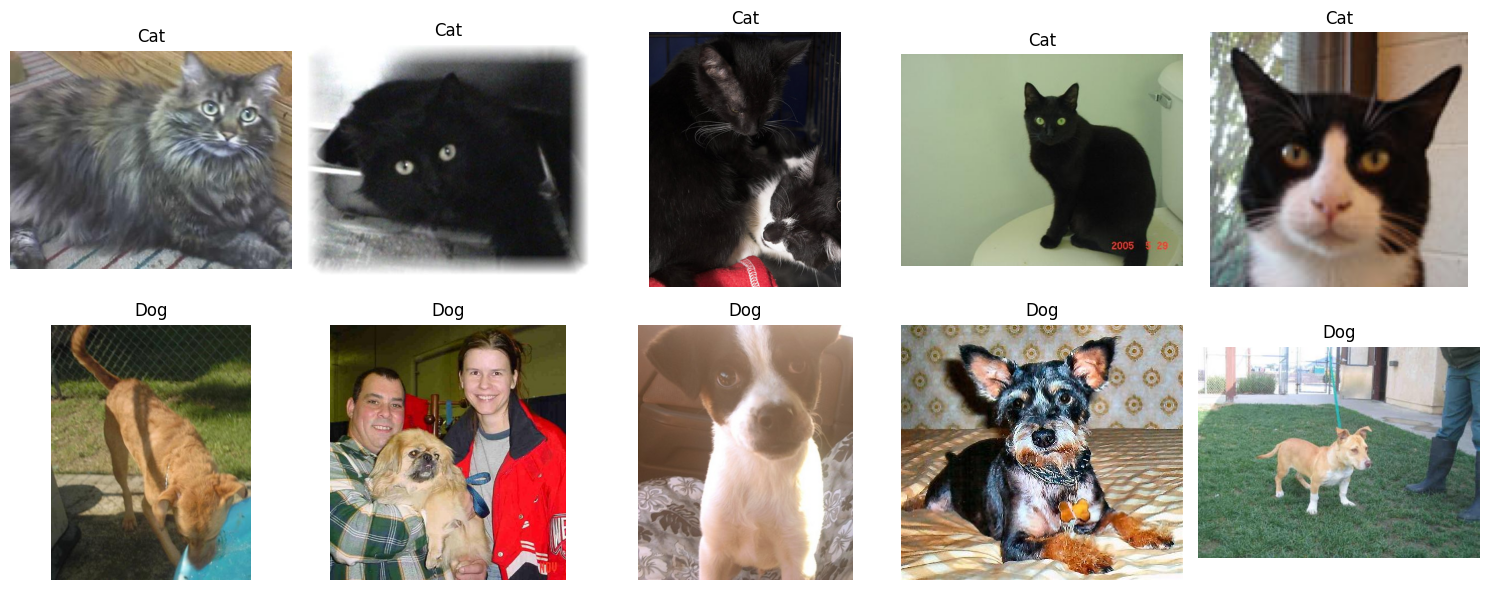

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Get five filenames from each class
cat_files = os.listdir(cat_dir)[:5]
dog_files = os.listdir(dog_dir)[:5]

# Create a figure with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Display five Cat images
for i, filename in enumerate(cat_files):
    path = os.path.join(cat_dir, filename)
    img = Image.open(path).convert("RGB")

    axes[0, i].imshow(img)
    axes[0, i].set_title("Cat")
    axes[0, i].axis("off")

# Display five Dog images
for i, filename in enumerate(dog_files):
    path = os.path.join(dog_dir, filename)
    img = Image.open(path).convert("RGB")

    axes[1, i].imshow(img)
    axes[1, i].set_title("Dog")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [13]:
from PIL import Image
import os

# Get one image from each class
cat_filename = os.listdir(cat_dir)[0]
dog_filename = os.listdir(dog_dir)[0]

# Create the complete paths
cat_path = os.path.join(cat_dir, cat_filename)
dog_path = os.path.join(dog_dir, dog_filename)

# Open both images
cat_image = Image.open(cat_path)
dog_image = Image.open(dog_path)

# Display their dimensions
print("Cat image size:", cat_image.size)
print("Dog image size:", dog_image.size)

Cat image size: (500, 387)
Dog image size: (391, 500)


In [14]:
import torch
from PIL import Image
from torchvision import transforms

# Define the image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Open one Cat image
image = Image.open(cat_path).convert("RGB")

# Apply the transformations
image_tensor = transform(image)

# Display the results
print("Original image size:", image.size)
print("Tensor shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)
print("Minimum pixel value:", image_tensor.min().item())
print("Maximum pixel value:", image_tensor.max().item())

Original image size: (500, 387)
Tensor shape: torch.Size([3, 128, 128])
Data type: torch.float32
Minimum pixel value: 0.1725490242242813
Maximum pixel value: 0.9411764740943909


#Next step: Build a custom PyTorch Dataset

In [15]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# Define how every image should be prepared
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Create our custom Dataset class
class CatDogDataset(Dataset):

    def __init__(self, cat_dir, dog_dir, transform=None):
        self.transform = transform
        self.samples = []

        # Collect Cat image paths: label 0
        for filename in os.listdir(cat_dir):
            path = os.path.join(cat_dir, filename)
            self.samples.append((path, 0))

        # Collect Dog image paths: label 1
        for filename in os.listdir(dog_dir):
            path = os.path.join(dog_dir, filename)
            self.samples.append((path, 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]

        with Image.open(path) as img:
            image = img.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [16]:
dataset = CatDogDataset(
    cat_dir=cat_dir,
    dog_dir=dog_dir,
    transform=transform
)

print("Total samples:", len(dataset))

image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", "Cat" if label == 0 else "Dog")

Total samples: 25002
Image shape: torch.Size([3, 128, 128])
Label: 0
Class: Cat


In [17]:
# Print the first image path and its label
print(dataset.samples[0])

('/content/cat_dog_cnn/dataset/PetImages/Cat/6663.jpg', 0)


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 0, 1, 1, 1, 0, 0, 0, 1])


#Find valid image files

In [19]:
from PIL import Image
import os

# Store valid image paths and labels here
valid_samples = []

# Check Cat images
for filename in os.listdir(cat_dir):
    path = os.path.join(cat_dir, filename)

    try:
        with Image.open(path) as img:
            img.verify()
        valid_samples.append((path, 0))
    except Exception:
        pass

# Check Dog images
for filename in os.listdir(dog_dir):
    path = os.path.join(dog_dir, filename)

    try:
        with Image.open(path) as img:
            img.verify()
        valid_samples.append((path, 1))
    except Exception:
        pass

print("Total valid images:", len(valid_samples))
print("Cat images:", sum(1 for _, label in valid_samples if label == 0))
print("Dog images:", sum(1 for _, label in valid_samples if label == 1))

Total valid images: 24998
Cat images: 12499
Dog images: 12499


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [20]:
from sklearn.model_selection import train_test_split

# Extract the labels from our valid samples
labels = [label for path, label in valid_samples]

# Split the samples into training and validation sets
train_samples, val_samples = train_test_split(
    valid_samples,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training images:", len(train_samples))
print("Validation images:", len(val_samples))

Training images: 19998
Validation images: 5000


In [21]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CatDogSplitDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]

        with Image.open(path) as img:
            image = img.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [22]:
train_dataset = CatDogSplitDataset(train_samples, transform=transform)
val_dataset = CatDogSplitDataset(val_samples, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 19998
Validation dataset: 5000


In [23]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)

Training images: torch.Size([32, 3, 128, 128])
Training labels: torch.Size([32])
Validation images: torch.Size([32, 3, 128, 128])
Validation labels: torch.Size([32])


In [24]:

from PIL import Image

clean_samples = []

for path, label in valid_samples:
    try:
        with Image.open(path) as img:
            img.load()
        clean_samples.append((path, label))
    except Exception:
        pass

print("Images that can be decoded:", len(clean_samples))
print("Images removed:", len(valid_samples) - len(clean_samples))


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Images that can be decoded: 24998
Images removed: 0


#Build CNN for 128 × 128 images

In [25]:

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.fc = nn.Linear(32 * 32 * 32, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)

        return x

model = CNN()

print(model)


CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=32768, out_features=2, bias=True)
)


In [26]:

dummy_images = torch.randn(4, 3, 128, 128)

outputs = model(dummy_images)

print("Input shape:", dummy_images.shape)
print("Output shape:", outputs.shape)
print("Output scores:", outputs)


Input shape: torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 2])
Output scores: tensor([[ 0.1219, -0.2531],
        [ 0.1787, -0.3038],
        [ 0.2768, -0.4339],
        [ 0.1198, -0.3301]], grad_fn=<AddmmBackward0>)


In [28]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Device:", device)
print("Loss function:", criterion)
print("Optimizer:", type(optimizer).__name__)


Device: cuda
Loss function: CrossEntropyLoss()
Optimizer: Adam


In [29]:

model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)

    predictions = outputs.argmax(dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

epoch_loss = running_loss / total
epoch_accuracy = 100 * correct / total

print(f"Training Loss: {epoch_loss:.4f}")
print(f"Training Accuracy: {epoch_accuracy:.2f}%")


Training Loss: 0.6688
Training Accuracy: 59.75%


#Let's evaluate the model on the 5,000 validation images it did not train on. This helps us understand whether it generalizes to unseen images.

In [30]:

model.eval()

val_loss_total = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss_total += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        val_correct += (predictions == labels).sum().item()
        val_total += labels.size(0)

val_loss = val_loss_total / val_total
val_accuracy = 100 * val_correct / val_total

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")


Validation Loss: 0.6315
Validation Accuracy: 63.46%


#train for four more epochs

In [31]:

for epoch in range(2, 6):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch {epoch}/5 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )


Epoch 2/5 | Train Loss: 0.6061 | Train Accuracy: 66.95% | Val Loss: 0.6134 | Val Accuracy: 66.78%
Epoch 3/5 | Train Loss: 0.5625 | Train Accuracy: 70.94% | Val Loss: 0.5654 | Val Accuracy: 71.24%
Epoch 4/5 | Train Loss: 0.5289 | Train Accuracy: 73.26% | Val Loss: 0.5491 | Val Accuracy: 72.38%
Epoch 5/5 | Train Loss: 0.4908 | Train Accuracy: 76.44% | Val Loss: 0.5226 | Val Accuracy: 74.12%


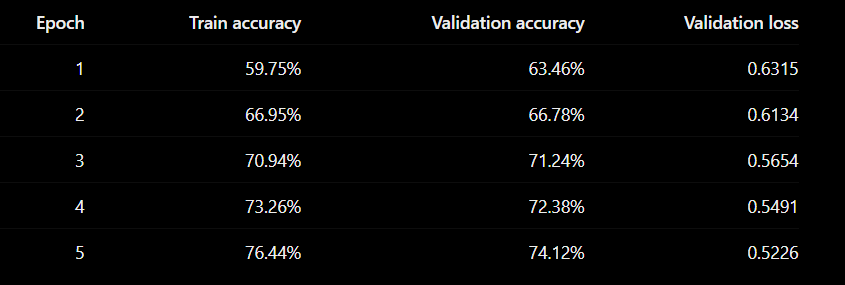

#Training for epochs from 6 to 15

In [32]:

for epoch in range(6, 16):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch {epoch}/15 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )


Epoch 6/15 | Train Loss: 0.4527 | Train Accuracy: 78.51% | Val Loss: 0.5098 | Val Accuracy: 74.76%
Epoch 7/15 | Train Loss: 0.4233 | Train Accuracy: 80.54% | Val Loss: 0.5028 | Val Accuracy: 76.52%
Epoch 8/15 | Train Loss: 0.3970 | Train Accuracy: 82.06% | Val Loss: 0.5064 | Val Accuracy: 76.54%
Epoch 9/15 | Train Loss: 0.3727 | Train Accuracy: 83.45% | Val Loss: 0.5251 | Val Accuracy: 75.74%
Epoch 10/15 | Train Loss: 0.3436 | Train Accuracy: 84.67% | Val Loss: 0.5440 | Val Accuracy: 75.60%
Epoch 11/15 | Train Loss: 0.3236 | Train Accuracy: 85.96% | Val Loss: 0.5638 | Val Accuracy: 75.02%
Epoch 12/15 | Train Loss: 0.2945 | Train Accuracy: 87.46% | Val Loss: 0.5800 | Val Accuracy: 75.02%
Epoch 13/15 | Train Loss: 0.2732 | Train Accuracy: 88.56% | Val Loss: 0.6120 | Val Accuracy: 74.62%
Epoch 14/15 | Train Loss: 0.2511 | Train Accuracy: 89.55% | Val Loss: 0.6621 | Val Accuracy: 74.86%
Epoch 15/15 | Train Loss: 0.2312 | Train Accuracy: 90.64% | Val Loss: 0.6667 | Val Accuracy: 74.02%


In [33]:

import torch

torch.save(model.state_dict(), "/content/cat_dog_cnn_model.pth")

print("Model weights saved successfully!")


Model weights saved successfully!


#Choose an image from your dataset

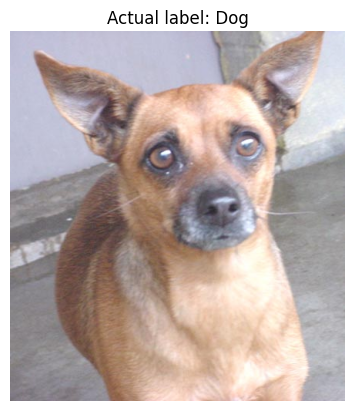

In [34]:

import random
from PIL import Image
import matplotlib.pyplot as plt

image_path, true_label = random.choice(val_samples)

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Actual label: " + ("Cat" if true_label == 0 else "Dog"))
plt.show()


#Make the CNN predict on one unseen validation image

In [35]:

from PIL import Image

image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    outputs = model(image_tensor)
    predicted_class = outputs.argmax(dim=1).item()

class_names = ["Cat", "Dog"]

print("Actual label:", class_names[true_label])
print("Predicted label:", class_names[predicted_class])
print("Raw model scores:", outputs.cpu().numpy())


Actual label: Dog
Predicted label: Dog
Raw model scores: [[-1.1257863  1.1153792]]


In [36]:

import torch.nn.functional as F

probabilities = F.softmax(outputs, dim=1)

print("Cat probability:", f"{probabilities[0, 0].item() * 100:.2f}%")
print("Dog probability:", f"{probabilities[0, 1].item() * 100:.2f}%")


Cat probability: 9.61%
Dog probability: 90.39%


#Test 100 unseen validation images

In [37]:

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        if total >= 100:
            break

accuracy = 100 * correct / total

print("Images evaluated:", total)
print("Correct predictions:", correct)
print("Incorrect predictions:", total - correct)
print(f"Accuracy: {accuracy:.2f}%")


Images evaluated: 128
Correct predictions: 97
Incorrect predictions: 31
Accuracy: 75.78%


This code evaluates the first batches returned by your validation loader. Because shuffle=False, these are not a randomly selected sample of 100 images. Also, the resulting accuracy is only a small-sample check; your earlier full validation accuracy of 74.02% is the more comprehensive measure.

#Next, let's inspect the mistakes
Accuracy tells us how often the model is correct. Looking at individual predictions can help us understand what kinds of images it struggles with.

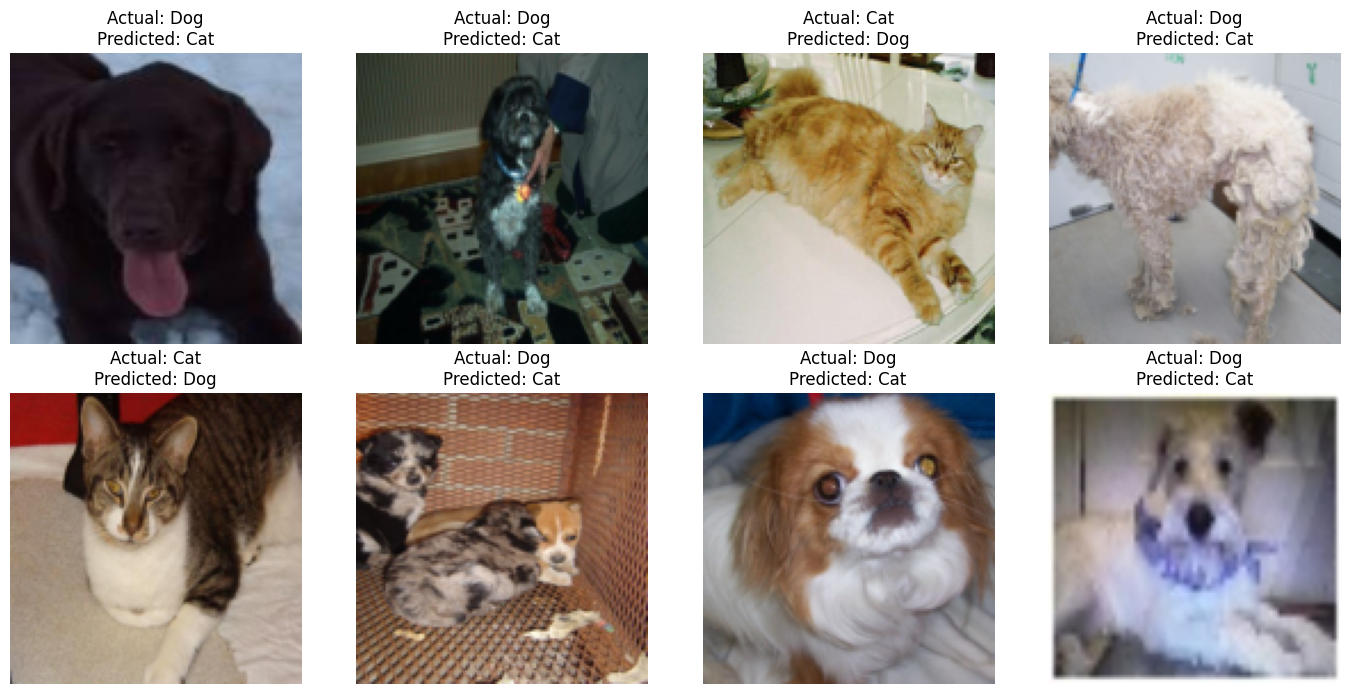

In [38]:

import matplotlib.pyplot as plt

model.eval()
wrong_images = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        wrong_indices = (predictions != labels).nonzero(as_tuple=True)[0]

        for idx in wrong_indices:
            wrong_images.append((
                images[idx].cpu(),
                labels[idx].item(),
                predictions[idx].item()
            ))

            if len(wrong_images) == 8:
                break

        if len(wrong_images) == 8:
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (image, actual, predicted) in zip(axes.flat, wrong_images):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(
        f"Actual: {class_names[actual]}\nPredicted: {class_names[predicted]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


#CNN with data augmentation

Create separate transformations

Training images: resize, randomly flip, slightly rotate, then convert to tensors.


Validation images: only resize and convert to tensors, keeping evaluation consistent.

In [40]:

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

print("Training and validation transforms are ready!")


Training and validation transforms are ready!


#Update the existing datasets

In [41]:

train_dataset.transform = train_transform
val_dataset.transform = val_transform

print("Training augmentation enabled:", train_dataset.transform)
print("Validation transform:", val_dataset.transform)


Training augmentation enabled: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)
Validation transform: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


#Visualize augmented images

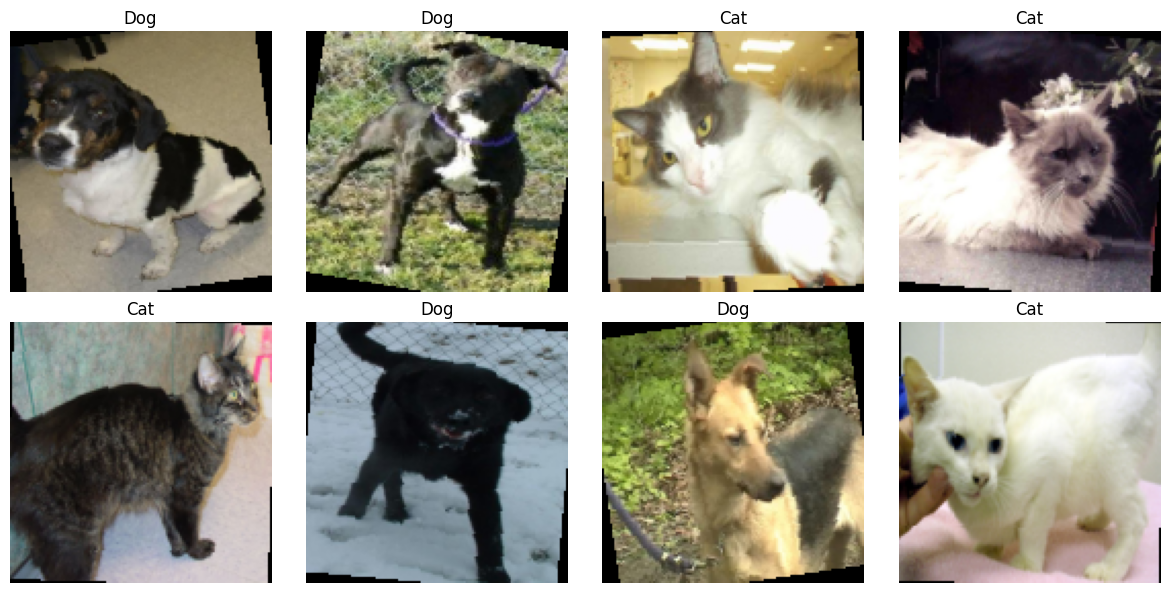

In [42]:

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0))
    ax.set_title("Cat" if labels[i].item() == 0 else "Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()


#Train an improved CNN fairly

In [43]:

augmented_model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

augmented_optimizer = torch.optim.Adam(
    augmented_model.parameters(),
    lr=0.001
)

print("New CNN created on:", next(augmented_model.parameters()).device)
print("Optimizer: Adam")
print("Learning rate: 0.001")


New CNN created on: cuda:0
Optimizer: Adam
Learning rate: 0.001


#Train the augmented CNN for 15 epochs

In [44]:

augmented_history = []

for epoch in range(1, 16):
    augmented_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        augmented_optimizer.zero_grad()

        outputs = augmented_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        augmented_optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    augmented_model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = augmented_model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = 100 * val_correct / val_total

    augmented_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch}/15 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )


Epoch 1/15 | Train Loss: 0.6504 | Train Accuracy: 61.83% | Val Loss: 0.5859 | Val Accuracy: 68.56%
Epoch 2/15 | Train Loss: 0.5758 | Train Accuracy: 70.40% | Val Loss: 0.5244 | Val Accuracy: 74.74%
Epoch 3/15 | Train Loss: 0.5235 | Train Accuracy: 74.32% | Val Loss: 0.5045 | Val Accuracy: 75.78%
Epoch 4/15 | Train Loss: 0.4967 | Train Accuracy: 75.91% | Val Loss: 0.4744 | Val Accuracy: 77.92%
Epoch 5/15 | Train Loss: 0.4732 | Train Accuracy: 77.65% | Val Loss: 0.4588 | Val Accuracy: 78.72%
Epoch 6/15 | Train Loss: 0.4549 | Train Accuracy: 78.59% | Val Loss: 0.4714 | Val Accuracy: 78.06%
Epoch 7/15 | Train Loss: 0.4445 | Train Accuracy: 79.70% | Val Loss: 0.4335 | Val Accuracy: 79.84%
Epoch 8/15 | Train Loss: 0.4284 | Train Accuracy: 80.46% | Val Loss: 0.4385 | Val Accuracy: 79.94%
Epoch 9/15 | Train Loss: 0.4227 | Train Accuracy: 80.80% | Val Loss: 0.4267 | Val Accuracy: 80.76%
Epoch 10/15 | Train Loss: 0.4129 | Train Accuracy: 81.30% | Val Loss: 0.4147 | Val Accuracy: 80.84%
Epoch 11/

In [45]:
print("Augmented model exists:", "augmented_model" in globals())
print("Optimizer exists:", "augmented_optimizer" in globals())
print("Training history exists:", "augmented_history" in globals())

Augmented model exists: True
Optimizer exists: True
Training history exists: True


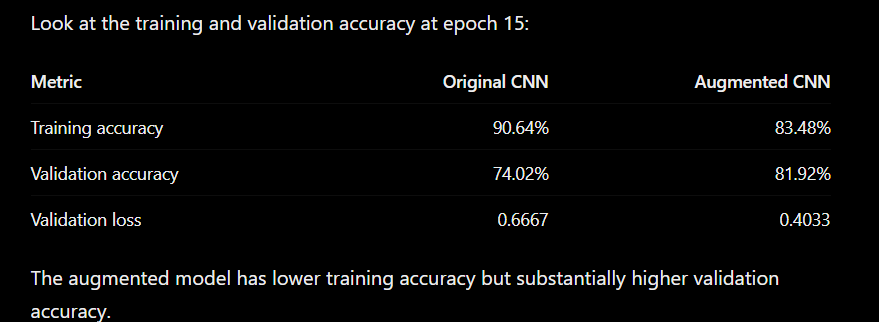

In [46]:

torch.save(
    augmented_model.state_dict(),
    "/content/cat_dog_cnn_augmented.pth"
)

print("Augmented CNN saved successfully!")


Augmented CNN saved successfully!


# Evaluate the augmented CNN on the full validation set
We'll use all 5,000 validation images.

In [47]:

import torch
from sklearn.metrics import confusion_matrix, classification_report

augmented_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = augmented_model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Cat", "Dog"],
        digits=4
    )
)


Confusion Matrix:
[[2023  477]
 [ 427 2073]]

Classification Report:
              precision    recall  f1-score   support

         Cat     0.8257    0.8092    0.8174      2500
         Dog     0.8129    0.8292    0.8210      2500

    accuracy                         0.8192      5000
   macro avg     0.8193    0.8192    0.8192      5000
weighted avg     0.8193    0.8192    0.8192      5000



In [49]:
import shutil
import os

project_dir = "/content/cat_dog_cnn"

shutil.move(
    "/content/cat_dog_cnn_model.pth",
    os.path.join(project_dir, "cat_dog_cnn_model.pth")
)

shutil.move(
    "/content/cat_dog_cnn_augmented.pth",
    os.path.join(project_dir, "cat_dog_cnn_augmented.pth")
)

print("Both model files moved into the project folder!")

Both model files moved into the project folder!


#Create a reusable prediction function

In [50]:

import torch
from PIL import Image
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/cat_dog_cnn/cat_dog_cnn_augmented.pth"

model = CNN().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

class_names = ["Cat", "Dog"]

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = probabilities.argmax(dim=1).item()

    print("Predicted class:", class_names[predicted_class])
    print("Cat score:", f"{probabilities[0, 0].item() * 100:.2f}%")
    print("Dog score:", f"{probabilities[0, 1].item() * 100:.2f}%")

print("Prediction function is ready!")


Prediction function is ready!


In [51]:

predict_image(image_path)


Predicted class: Dog
Cat score: 7.33%
Dog score: 92.67%


#Upload your own image

In [52]:

from google.colab import files

uploaded = files.upload()


Saving beagle-hound-dog.webp to beagle-hound-dog.webp


In [53]:

uploaded_image_path = next(iter(uploaded.keys()))

predict_image(uploaded_image_path)


Predicted class: Dog
Cat score: 0.89%
Dog score: 99.11%


In [58]:
import os

# Define the path to your project folder
project_dir = "/content/cat_dog_cnn"

# Create the results folder inside your project
results_dir = os.path.join(project_dir, "results")

# Create the folder if it doesn't already exist
os.makedirs(results_dir, exist_ok=True)

print("Results folder created at:", results_dir)

Results folder created at: /content/cat_dog_cnn/results


## Visualize Training Performance

We plot training and validation accuracy and loss across epochs to understand how the CNN learns and how well it generalizes to unseen validation images.

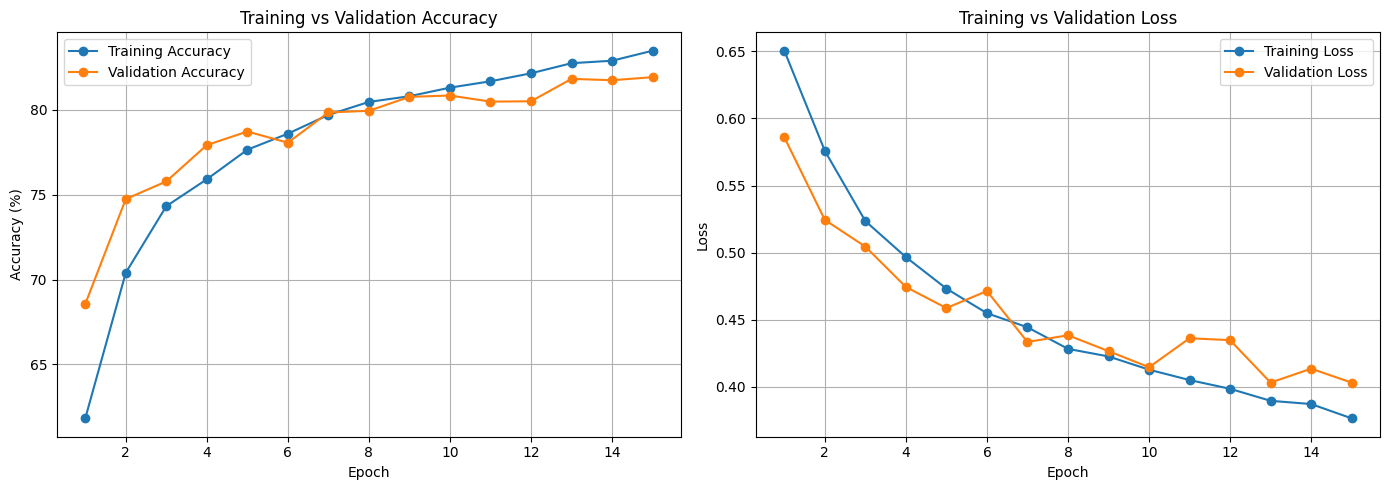

In [59]:
import matplotlib.pyplot as plt

# Extract metrics from the training history
epochs = [item["epoch"] for item in augmented_history]
train_accuracy = [item["train_accuracy"] for item in augmented_history]
val_accuracy = [item["val_accuracy"] for item in augmented_history]
train_loss = [item["train_loss"] for item in augmented_history]
val_loss = [item["val_loss"] for item in augmented_history]

# Create two graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Accuracy
axes[0].plot(epochs, train_accuracy, label="Training Accuracy", marker="o")
axes[0].plot(epochs, val_accuracy, label="Validation Accuracy", marker="o")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True)

# Graph 2: Loss
axes[1].plot(epochs, train_loss, label="Training Loss", marker="o")
axes[1].plot(epochs, val_loss, label="Validation Loss", marker="o")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

### Training and Validation Analysis

The training and validation accuracy curves show an overall improvement in classification performance across 15 epochs. Training accuracy reached 83.48%, while validation accuracy reached 81.92%. Training and validation loss generally decreased during training, indicating that the CNN learned useful features for distinguishing cats from dogs. Although validation loss fluctuated slightly in some epochs, the final results suggest reasonable generalization with a modest gap between training and validation performance.

The reported accuracy is measured on the validation set; performance on a separate, independent test set has not yet been established.

## Confusion Matrix Visualization

A confusion matrix shows how many images the CNN classified correctly and how many it misclassified. It helps us understand the model's performance on the Cat and Dog classes individually.

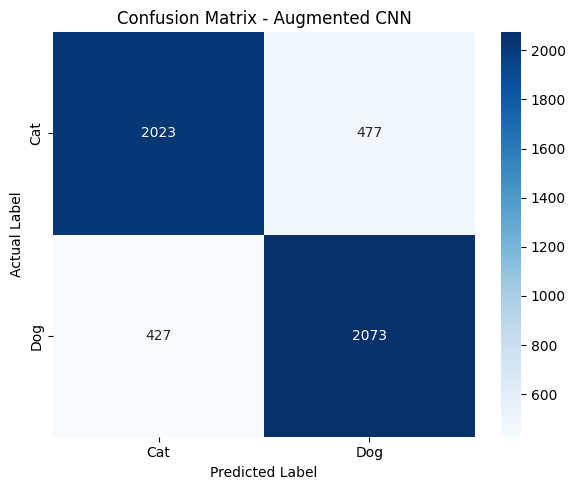

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Create the heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.title("Confusion Matrix - Augmented CNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

### Confusion Matrix Analysis

The augmented CNN correctly classified 2,023 cat images and 2,073 dog images from the 5,000-image validation set. It misclassified 477 cat images as dogs and 427 dog images as cats. The overall validation accuracy was 81.92%, with a slightly higher recall for the Dog class (82.92%) than the Cat class (80.92%). These results show that the model can distinguish between the two classes, although some misclassifications remain.

## Original CNN vs Augmented CNN

This experiment compares a baseline CNN trained without data augmentation against a CNN trained with random horizontal flipping and random rotation. Both models use the same CNN architecture and are evaluated using validation accuracy.

,Model,Best Validation Accuracy (%)
0,Original CNN,76.54
1,Augmented CNN,81.92


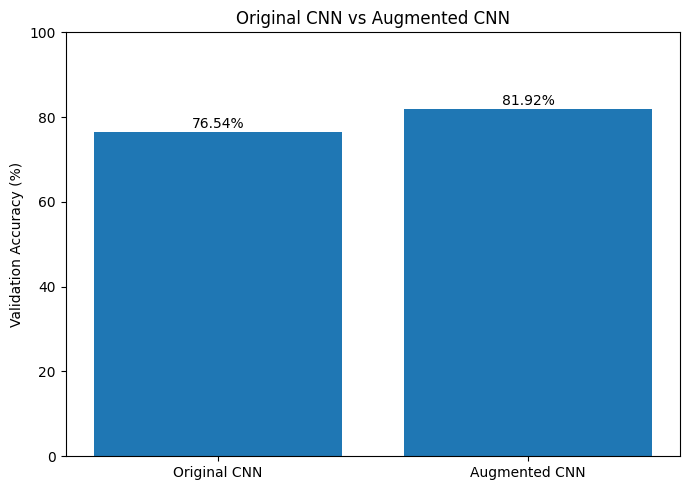

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# Record the best validation accuracy from each experiment
comparison = pd.DataFrame({
    "Model": ["Original CNN", "Augmented CNN"],
    "Best Validation Accuracy (%)": [76.54, 81.92]
})

# Display the comparison table
display(comparison)

# Plot the validation accuracy comparison
plt.figure(figsize=(7, 5))

bars = plt.bar(
    comparison["Model"],
    comparison["Best Validation Accuracy (%)"]
)

plt.title("Original CNN vs Augmented CNN")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(0, 100)

# Display the accuracy above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "model_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

### Comparison Results

The baseline CNN achieved a best validation accuracy of 76.54%, while the CNN trained with data augmentation achieved 81.92%. This represents an improvement of 5.38 percentage points. The result suggests that random horizontal flipping and rotation helped the model learn features that generalized better to the validation images. However, further evaluation on an independent test set is needed to confirm the improvement.

In [ ]:
import os
import zipfile

project_dir = "/content/cat_dog_cnn"
zip_path = "/content/cat_dog_cnn_project.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(project_dir):
        # Skip the dataset directory
        dirs[:] = [d for d in dirs if d != "dataset"]

        for file in files:
            # Skip the downloaded dataset archive
            if file == "catsdogs.zip":
                continue

            full_path = os.path.join(root, file)
            relative_path = os.path.relpath(full_path, project_dir)
            zipf.write(full_path, relative_path)

print("ZIP created successfully!")
print("File size (MB):", round(os.path.getsize(zip_path) / (1024 * 1024), 2))

In [ ]:
from google.colab import files

uploaded = files.upload()